In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

In [3]:
print("Train Shape: ",train.shape)
print("Test Shape: ",test.shape)

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)


In [4]:
train['MasVnrType'] = train['MasVnrType'].fillna('None')
test['MasVnrType'] = test['MasVnrType'].fillna('None')

In [5]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [7]:
print(train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


<Axes: >

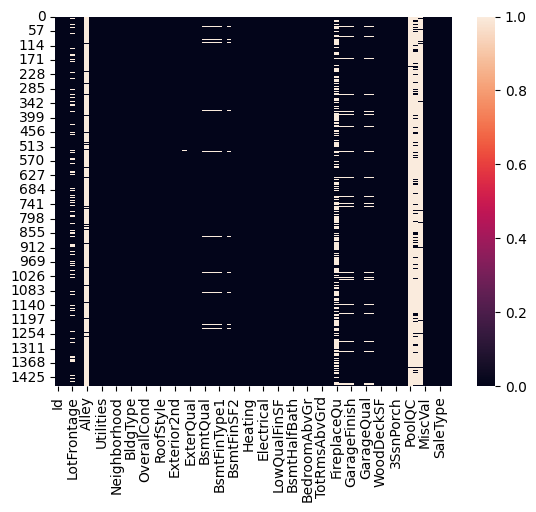

In [8]:
sns.heatmap(train.isnull())

In [9]:
print(test.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

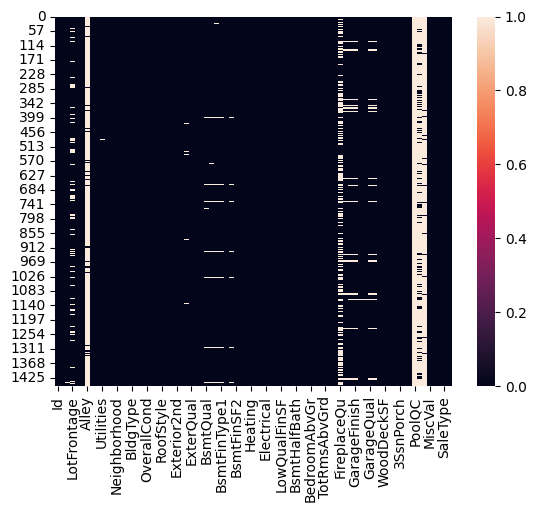

In [10]:
sns.heatmap(test.isnull())

In [11]:
cat_col_train = ['FireplaceQu','GarageType','GarageFinish','MasVnrType','BsmtQual',
           'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu',
          'GarageQual','GarageCond']

ncat_col_train = ['LotFrontage','GarageYrBlt','MasVnrArea']

In [12]:
for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])
    
for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

In [13]:
cat_col_test = ['FireplaceQu','GarageType','GarageFinish','MasVnrType','BsmtQual',
           'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu',
          'GarageQual','GarageCond','MSZoning','Utilities','Exterior1st','Exterior2nd','KitchenQual','Functional','SaleType']

ncat_col_test = ['LotFrontage','GarageYrBlt','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath',
                'BsmtHalfBath','GarageCars','GarageArea']

In [14]:
for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])
    
for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

In [15]:
to_drop = ['Id','Alley','PoolQC','Fence','MiscFeature']

for k in to_drop:
    train.drop([k], axis = 1, inplace = True)
    test.drop([k], axis = 1, inplace = True)

<Axes: >

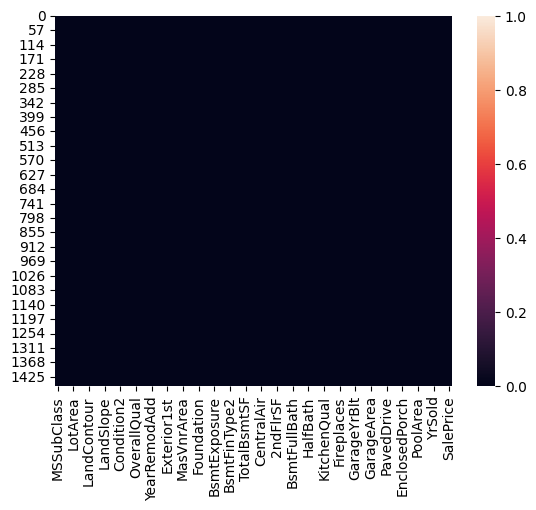

In [16]:
sns.heatmap(train.isnull())

<Axes: >

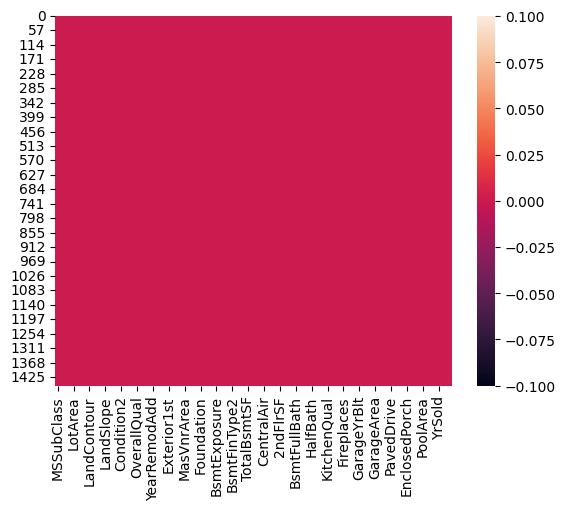

In [17]:
sns.heatmap(test.isnull())

In [18]:
print("Train Shape: ",train.shape)
print("Test Shape: ",test.shape)

Train Shape:  (1460, 76)
Test Shape:  (1459, 75)


In [19]:
final_df = pd.concat([train,test], axis = 0)
final_df.shape

(2919, 76)

In [20]:
all_cat_col = ['MSZoning','Street','LotShape','LandContour','Utilities','LotConfig','LandSlope',
              'Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl',
              'Exterior1st','Exterior2nd','MasVnrType','ExterQual','ExterCond','Foundation','BsmtQual',
              'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','Heating','HeatingQC','CentralAir',
              'Electrical','KitchenQual','Functional','FireplaceQu','GarageType','GarageFinish','GarageQual',
              'GarageCond','PavedDrive','SaleType','SaleCondition']

In [21]:
def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0
    for fields in multicol:
        print(fields)
        df1 = pd.get_dummies(final_df[fields],drop_first = True)
        
        final_df.drop([fields], axis = 1, inplace = True)
        if i==0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final,df1], axis=1)
        i = i+1
    
    df_final = pd.concat([final_df,df_final], axis = 1)
    
    return df_final

In [22]:
final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


In [23]:
final_df.shape

(2919, 237)

In [24]:
final_df = final_df.loc[:,~final_df.columns.duplicated()]
final_df.shape

(2919, 177)

In [25]:
df_train = final_df.iloc[:1460,:]
df_test = final_df.iloc[1460:,:]

In [26]:
df_test = df_test.drop(['SalePrice'], axis=1)

In [27]:
print("Train Shape: ",df_train.shape)
print("Test Shape: ",df_test.shape)

Train Shape:  (1460, 177)
Test Shape:  (1459, 176)


In [28]:
x_train = df_train.drop(['SalePrice'], axis = 1)
y_train = df_train['SalePrice']

In [29]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

# 1. Khởi tạo mô hình XGBoost với random_state = 42
xgb_model = xgb.XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

# 2. Không gian tham số chuẩn xác từ bài viết gốc
param_dist = {
    'n_estimators': [100, 500, 900, 1100, 1500],
    'max_depth': [2, 3, 5, 10, 15],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1, 2, 3, 4]
}

# 3. Khởi tạo RandomizedSearchCV với các tham số cố định
random_cv = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    cv=5,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    n_jobs=4,
    verbose=5,
    return_train_score=True,
    random_state=42
)

# 4. Huấn luyện
random_cv.fit(x_train, y_train)

# 5. Kiểm tra kết quả
random_cv.best_estimator_



Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 4/5] END learning_rate=0.15, max_depth=2, min_child_weight=2, n_estimators=1500;, score=(train=-3732.292, test=-14175.610) total time=   2.9s
[CV 3/5] END learning_rate=0.15, max_depth=15, min_child_weight=1, n_estimators=100;, score=(train=-5.236, test=-18709.724) total time=   5.6s
[CV 2/5] END learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=1100;, score=(train=-4826.761, test=-15883.712) total time=   2.6s
[CV 5/5] END learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=1100;, score=(train=-4880.834, test=-16743.247) total time=   2.6s
[CV 3/5] END learning_rate=0.15, max_depth=2, min_child_weight=3, n_estimators=100;, score=(train=-12831.378, test=-18131.114) total time=   0.3s
[CV 2/5] END learning_rate=0.05, max_depth=15, min_child_weight=3, n_estimators=1100;, score=(train=-7.890, test=-19739.974) total time=  20.0s
[CV 1/5] END learning_rate=0.05, max_depth=15, min_child_weight=1, 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)

In [30]:
import xgboost as xgb

# Đầy đủ tất cả tham số như link gốc nhưng đã xóa gpu_id=-1 bị lỗi
xgb_model = xgb.XGBRegressor(
    base_score=0.25, 
    booster='gbtree', 
    colsample_bylevel=1,
    colsample_bynode=1, 
    colsample_bytree=1, 
    gamma=0,
    importance_type='gain', 
    interaction_constraints='',
    learning_rate=0.1, 
    max_delta_step=0, 
    max_depth=2,
    min_child_weight=1, 
    monotone_constraints='()',
    n_estimators=900, 
    n_jobs=0, 
    num_parallel_tree=1,
    objective='reg:squarederror', 
    random_state=0, 
    reg_alpha=0,
    reg_lambda=1, 
    scale_pos_weight=1, 
    subsample=1, 
    tree_method='exact',
    validate_parameters=1, 
    verbosity=None
)

# Huấn luyện mô hình
xgb_model.fit(x_train, y_train)


XGBRegressor(base_score=0.25, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=True,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0, grow_policy=None, importance_type='gain',
             interaction_constraints='', learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=0,
             max_depth=2, max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints='()', multi_strategy=None, n_estimators=900,
             n_jobs=0, num_parallel_tree=1, ...)

In [31]:
f = "xgb_model.pkl"
pickle.dump(xgb_model,open(f,'wb'))

In [32]:
pred_xgb = xgb_model.predict(df_test)
print(pred_xgb.shape)

(1459,)


In [33]:
from sklearn.tree import DecisionTreeRegressor

# Đổi từ Classifier (Phân loại) sang Regressor (Hồi quy)
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [34]:
pred_dt = dt_model.predict(df_test)
print(pred_dt.shape)

(1459,)


In [35]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import glob

print("1. Đang tải và tiền xử lý dữ liệu...")
train_path = glob.glob('/kaggle/input/**/train.csv', recursive=True)[0]
test_path = glob.glob('/kaggle/input/**/test.csv', recursive=True)[0]

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
train = train.drop(columns=to_drop, errors='ignore')
test = test.drop(columns=to_drop, errors='ignore')

train.fillna(train.mean(numeric_only=True), inplace=True)
test.fillna(test.mean(numeric_only=True), inplace=True)

for col in train.select_dtypes(include='object').columns:
    train[col] = train[col].fillna(train[col].mode()[0])
for col in test.select_dtypes(include='object').columns:
    test[col] = test[col].fillna(test[col].mode()[0])

y_train = train['SalePrice']
X_train_raw = train.drop('SalePrice', axis=1)

final_df = pd.concat([X_train_raw, test], axis=0, ignore_index=True)
final_df = pd.get_dummies(final_df, drop_first=True)

x_train = final_df.iloc[:len(train), :].copy()
x_test = final_df.iloc[len(train):, :].copy()

print("2. Đang chuẩn hóa dữ liệu và tạo PyTorch DataLoader...")
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

X_tr_tensor = torch.tensor(X_tr_scaled, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr_tensor, y_tr_tensor), batch_size=32, shuffle=True)

# 3. Định nghĩa mạng MLP
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super(MLPRegressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.network(x)

mlp_model = MLPRegressor(X_tr_scaled.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.005)

# 4. Huấn luyện và in ra tiến trình Loss
print("\n--- BẮT ĐẦU HUẤN LUYỆN PYTORCH MLP ---")
mlp_model.train()
for epoch in range(1, 101):
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if epoch % 20 == 0 or epoch == 1:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch:3d}/100 | Loss (MSE): {avg_loss:,.2f}")

# 5. Thực hiện dự đoán và in kết quả ra màn hình (Console Output)
mlp_model.eval()
with torch.no_grad():
    pred_nn = mlp_model(X_test_tensor).numpy().flatten()

print("\n--- KẾT QUẢ DỰ ĐOÁN GIÁ NHÀ (5 DÒNG ĐẦU TIÊN) ---")
print(pred_nn[:5])

1. Đang tải và tiền xử lý dữ liệu...
2. Đang chuẩn hóa dữ liệu và tạo PyTorch DataLoader...

--- BẮT ĐẦU HUẤN LUYỆN PYTORCH MLP ---
Epoch   1/100 | Loss (MSE): 38,821,140,301.91
Epoch  20/100 | Loss (MSE): 1,450,462,974.61
Epoch  40/100 | Loss (MSE): 991,471,507.48
Epoch  60/100 | Loss (MSE): 718,931,267.30
Epoch  80/100 | Loss (MSE): 627,361,438.96
Epoch 100/100 | Loss (MSE): 572,336,225.39

--- KẾT QUẢ DỰ ĐOÁN GIÁ NHÀ (5 DÒNG ĐẦU TIÊN) ---
[121724.74 151132.06 179164.77 191725.39 178668.3 ]


In [37]:
import glob

# Tự động tìm đúng đường dẫn file test.csv
test_path = glob.glob('/kaggle/input/**/test.csv', recursive=True)[0]
test_orig = pd.read_csv(test_path)

sub_df = pd.DataFrame({
    'Id': test_orig['Id'],
    'SalePrice': pred_nn  # Hoặc thay bằng pred_dt nếu muốn nộp kết quả của DecisionTree
})

sub_df.to_csv('submission_mlp.csv', index=False)
print("Đã xuất thành công file submission_mlp.csv!")

Đã xuất thành công file submission_mlp.csv!
